<a href="https://colab.research.google.com/github/Zaki2409/AI-Engineer-Hands-on/blob/master/Pytorch_NN_Training_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install numpy pandas torch scikit-learn

In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

import torch.nn as nn

In [2]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')

In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
df.shape

(569, 33)

In [6]:
df.drop(columns=['id','Unnamed: 32'], inplace=True)

In [7]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
#df.iloc[0]
#df.iloc[:] = df.head()
# all expect the target for x train and x test df.iloc[:,1:]
# only the target for y test and y train df.iloc[:,0]

In [91]:
df_train, df_test = train_test_split(df, test_size=0.2)

In [92]:
df_test.shape

(114, 31)

In [93]:
df_train.shape

(455, 31)

In [94]:
X_train = df_train.iloc[:,1:]
Y_train = df_train.iloc[:,0]

In [95]:
X_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
207,17.010,20.26,109.70,904.3,0.08772,0.07304,0.06950,0.05390,0.2026,0.05223,...,19.80,25.05,130.00,1210.0,0.11110,0.14860,0.19320,0.10960,0.3275,0.06469
561,11.200,29.37,70.67,386.0,0.07449,0.03558,0.00000,0.00000,0.1060,0.05502,...,11.92,38.30,75.19,439.6,0.09267,0.05494,0.00000,0.00000,0.1566,0.05905
389,19.550,23.21,128.90,1174.0,0.10100,0.13180,0.18560,0.10210,0.1989,0.05884,...,20.82,30.44,142.00,1313.0,0.12510,0.24140,0.38290,0.18250,0.2576,0.07602
555,10.290,27.61,65.67,321.4,0.09030,0.07658,0.05999,0.02738,0.1593,0.06127,...,10.84,34.91,69.57,357.6,0.13840,0.17100,0.20000,0.09127,0.2226,0.08283
153,11.150,13.08,70.87,381.9,0.09754,0.05113,0.01982,0.01786,0.1830,0.06105,...,11.99,16.30,76.25,440.8,0.13410,0.08971,0.07116,0.05506,0.2859,0.06772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504,9.268,12.87,61.49,248.7,0.16340,0.22390,0.09730,0.05252,0.2378,0.09502,...,10.28,16.38,69.05,300.2,0.19020,0.34410,0.20990,0.10250,0.3038,0.12520
289,11.370,18.89,72.17,396.0,0.08713,0.05008,0.02399,0.02173,0.2013,0.05955,...,12.36,26.14,79.29,459.3,0.11180,0.09708,0.07529,0.06203,0.3267,0.06994
304,11.460,18.16,73.59,403.1,0.08853,0.07694,0.03344,0.01502,0.1411,0.06243,...,12.68,21.61,82.69,489.8,0.11440,0.17890,0.12260,0.05509,0.2208,0.07638
487,19.440,18.82,128.10,1167.0,0.10890,0.14480,0.22560,0.11940,0.1823,0.06115,...,23.96,30.39,153.90,1740.0,0.15140,0.37250,0.59360,0.20600,0.3266,0.09009


In [96]:
Y_train

,diagnosis
207,M
561,B
389,M
555,B
153,B
...,...
504,B
289,B
304,B
487,M


In [97]:
X_test = df_test.iloc[:,1:]
Y_test = df_test.iloc[:,0]

In [98]:
X_test

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
219,19.53,32.47,128.00,1223.0,0.08420,0.11300,0.114500,0.066370,0.1428,0.05313,...,27.90,45.41,180.20,2477.0,0.1408,0.40970,0.39950,0.16250,0.2713,0.07568
371,15.19,13.21,97.65,711.8,0.07963,0.06934,0.033930,0.026570,0.1721,0.05544,...,16.20,15.73,104.50,819.1,0.1126,0.17370,0.13620,0.08178,0.2487,0.06766
361,13.30,21.57,85.24,546.1,0.08582,0.06373,0.033440,0.024240,0.1815,0.05696,...,14.20,29.20,92.94,621.2,0.1140,0.16670,0.12120,0.05614,0.2637,0.06658
544,13.87,20.70,89.77,584.8,0.09578,0.10180,0.036880,0.023690,0.1620,0.06688,...,15.05,24.75,99.17,688.6,0.1264,0.20370,0.13770,0.06845,0.2249,0.08492
310,11.70,19.11,74.33,418.7,0.08814,0.05253,0.015830,0.011480,0.1936,0.06128,...,12.61,26.55,80.92,483.1,0.1223,0.10870,0.07915,0.05741,0.3487,0.06958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54,15.10,22.02,97.26,712.8,0.09056,0.07081,0.052530,0.033340,0.1616,0.05684,...,18.10,31.69,117.70,1030.0,0.1389,0.20570,0.27120,0.15300,0.2675,0.07873
537,11.69,24.44,76.37,406.4,0.12360,0.15520,0.045150,0.045310,0.2131,0.07405,...,12.98,32.19,86.12,487.7,0.1768,0.32510,0.13950,0.13080,0.2803,0.09970
340,14.42,16.54,94.15,641.2,0.09751,0.11390,0.080070,0.042230,0.1912,0.06412,...,16.67,21.51,111.40,862.1,0.1294,0.33710,0.37550,0.14140,0.3053,0.08764
315,12.49,16.85,79.19,481.6,0.08511,0.03834,0.004473,0.006423,0.1215,0.05673,...,13.34,19.71,84.48,544.2,0.1104,0.04953,0.01938,0.02784,0.1917,0.06174


In [99]:
Y_test

,diagnosis
219,M
371,B
361,B
544,B
310,B
...,...
54,M
537,B
340,B
315,B


In [100]:
scale= StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.fit_transform(X_test)

In [101]:
X_train

array([[ 0.79768415,  0.1979832 ,  0.70995886, ..., -0.08466643,
         0.57973983, -1.06703264],
       [-0.80376512,  2.25351433, -0.84924517, ..., -1.7321008 ,
        -2.10906776, -1.37755592],
       [ 1.49780139,  0.86360524,  1.47697698, ...,  1.01111794,
        -0.52001237, -0.44323321],
       ...,
       [-0.73209958, -0.27584945, -0.7325945 , ..., -0.90402453,
        -1.09899493, -0.42341257],
       [ 1.46748136, -0.12693062,  1.44501789, ...,  1.36435432,
         0.56557993,  0.33142328],
       [-0.37652823, -0.60527595, -0.37625066, ..., -0.52282986,
         0.25878211,  0.0825642 ]])

In [102]:
X_test

array([[ 1.7530038 ,  3.67432031,  1.70820883, ...,  0.81162818,
        -0.30384204, -0.44240819],
       [ 0.33300141, -1.54792722,  0.262811  , ..., -0.48841907,
        -0.72063399, -0.89913338],
       [-0.28538673,  0.71884274, -0.3282067 , ..., -0.90136768,
        -0.44400217, -0.96063752],
       ...,
       [ 0.0810655 , -0.64501526,  0.09612591, ...,  0.47179918,
         0.32319009,  0.23869321],
       [-0.55041022, -0.56096039, -0.61633378, ..., -1.35715729,
        -1.77183493, -1.23626718],
       [ 1.41272673, -0.37929342,  1.38912595, ...,  0.87282962,
        -0.67821711,  0.62651098]])

In [103]:
encoder = LabelEncoder()
Y_train = encoder.fit_transform(Y_train)
Y_test = encoder.fit_transform(Y_test)

In [104]:
Y_train

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,

In [105]:
Y_test

array([1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1])

CONVERT NUMPY TO TENSOR TO USE GPU

In [106]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_test_tensor  = torch.tensor(Y_test, dtype=torch.float32).to(device)

In [107]:
X_train_tensor.shape

torch.Size([455, 30])

In [108]:
X_test_tensor.shape

torch.Size([114, 30])

In [109]:
Y_test_tensor.shape

torch.Size([114])

In [110]:
Y_train_tensor.shape

torch.Size([455])

DATA SET AND DATA LOADER

In [111]:
from torch.utils.data import Dataset, DataLoader

In [112]:
class Customdataset(Dataset):
  def __init__(self, X, y): # X IS FEAURES AND y is label
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]


In [113]:
train_dataset = Customdataset(X_train_tensor, Y_train_tensor)
test_dataset = Customdataset(X_test_tensor, Y_test_tensor)

In [114]:
train_dataset[10]

(tensor([ 1.5695,  0.6244,  1.5209,  1.6623,  0.1482, -0.0432,  0.7123,  1.1544,
         -0.8333, -1.2388,  1.2214, -0.3731,  1.4002,  1.4901, -0.1915, -0.3689,
          0.0403,  0.5181, -0.8341, -0.6883,  2.2343,  0.8022,  2.3032,  2.5900,
          0.8154,  0.3800,  1.2413,  1.8574, -0.2179, -0.4361], device='cuda:0'),
 tensor(1., device='cuda:0'))

In [115]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

#DEFINING A MODEL

In [116]:
class MyNN2(nn.Module):

  def __init__(self,num_features):
    super().__init__()
    self.linear = nn.Linear(num_features,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self,features):
    out = self.linear(features)
    out = self.sigmoid(out)
    return out


In [117]:
loss_function = nn.BCELoss()

IMPORTATN PAPRAMS

In [118]:
learning_rate = 0.1
epochs = 25

TRAINING PARAMETER

In [119]:
# create model
model2 = MyNN2(X_train_tensor.shape[1]).to(device)

#optimizer
optimizer = torch.optim.SGD(model2.parameters(), lr=learning_rate)

#loss function
loss_function = nn.BCELoss()

In [120]:
# define loop
for epoch in range(epochs):
  for batch_feaures, batch_labels in train_loader:
    # forward pass
    y_pred = model2.forward(batch_feaures)

    # loss calculate
    loss = loss_function(y_pred, batch_labels.view(-1,1))

    # zero gradients
    optimizer.zero_grad()

    # backward pass
    loss.backward()

    # parameters update
    optimizer.step()


  print(f'Epoch: {epoch+1}, Loss:{loss.item()}')

Epoch: 1, Loss:0.4303527772426605
Epoch: 2, Loss:0.15369078516960144
Epoch: 3, Loss:0.3738628625869751
Epoch: 4, Loss:0.15367203950881958
Epoch: 5, Loss:0.07265003770589828
Epoch: 6, Loss:0.10689227283000946
Epoch: 7, Loss:0.10514624416828156
Epoch: 8, Loss:0.017877541482448578
Epoch: 9, Loss:0.06592219322919846
Epoch: 10, Loss:0.010849880054593086
Epoch: 11, Loss:0.033748190850019455
Epoch: 12, Loss:0.3146485388278961
Epoch: 13, Loss:0.0226235780864954
Epoch: 14, Loss:0.029155561700463295
Epoch: 15, Loss:0.09694824367761612
Epoch: 16, Loss:0.04206043854355812
Epoch: 17, Loss:0.31866705417633057
Epoch: 18, Loss:0.21899382770061493
Epoch: 19, Loss:0.050184234976768494
Epoch: 20, Loss:0.11881628632545471
Epoch: 21, Loss:0.09229292720556259
Epoch: 22, Loss:0.039269790053367615
Epoch: 23, Loss:0.010244721546769142
Epoch: 24, Loss:0.07675045728683472
Epoch: 25, Loss:0.041034866124391556


In [121]:
# model 2 evaluation with test loader

model2.eval() # set moodel to evaluation mode
accuracy_list =[]

with torch.no_grad():
  for batch_feaures, batch_labels in test_loader:
    y_pred = model2.forward(batch_feaures) # forward pass
    y_pred = (y_pred > 0.8).float() #convert probabalitlies to biary classification


    batch_accuracy = (y_pred.view(-1) == batch_labels).float().mean().item() #calcualte accuracy for the current batch
    accuracy_list.append(batch_accuracy)

#calcualte overall accuracy
  overall_accuracy = sum(accuracy_list) / len(accuracy_list)
  print(f'Accuracy: {overall_accuracy:4f}')

Accuracy: 0.978299


In [122]:
model2.linear.bias

Parameter containing:
tensor([-0.4045], device='cuda:0', requires_grad=True)

In [123]:
model2.linear.weight

Parameter containing:
tensor([[ 0.5094,  0.5766,  0.5820,  0.4032,  0.2997,  0.0794,  0.4920,  0.4795,
          0.3086, -0.3673,  0.5331, -0.0365,  0.2928,  0.5346,  0.1439, -0.3064,
         -0.1619,  0.0492, -0.2076, -0.2700,  0.6680,  0.7601,  0.7270,  0.7363,
          0.3860,  0.1172,  0.5729,  0.7015,  0.4334,  0.1447]],
       device='cuda:0', requires_grad=True)

In [124]:
!pip install torchinfo

In [125]:
from torchinfo import summary
summary(model2, input_size=(455, 30))

Layer (type:depth-idx)                   Output Shape              Param #
MyNN2                                    [455, 1]                  --
├─Linear: 1-1                            [455, 1]                  31
├─Sigmoid: 1-2                           [455, 1]                  --
Total params: 31
Trainable params: 31
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.05
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.06

In [126]:
#Prepare background data
#SHAP’s DeepExplainer needs a representative sample from the training set to learn the “base” distribution.
#Use a small subset (e.g., 100–200 rows) of your training data (already converted to tensor).


background = X_train_tensor[torch.randperm(len(X_train_tensor))[:100]]

In [127]:
#Create the SHAP explainer Use shap.DeepExplainer (designed for neural networks). It requires the model and the background dataset.
import shap
explainer = shap.DeepExplainer(model2, background)

In [128]:
#Compute SHAP values for the test set
#You have X_test_tensor_for_nnmodule (test features).
#You can compute SHAP values for all test instances or just a few.

shap_values = explainer.shap_values(X_test_tensor)

In [129]:
# shap_values is shape (455, 30, 1) – squeeze the last dimension
shap_vals = shap_values.squeeze(-1)   # now (455, 30)

In [130]:
#SHAP's plotting functions (summary_plot, waterfall_plot, etc.) require CPU‑based numpy arrays or pandas DataFrames. They cannot directly handle GPU tensors.
X_test_np = X_test_tensor.cpu().numpy()

In [131]:
#X_train.columns doesn't exist because X_train is now a NumPy array. Use the original column names from df:
feature_names = df.columns[1:].tolist()   # skip 'diagnosis'

In [132]:
print("type(shap_values):", type(shap_values))
if isinstance(shap_values, list):
    print("len(shap_values):", len(shap_values))
    for i, arr in enumerate(shap_values):
        print(f"shap_values[{i}].shape:", arr.shape)
else:
    print("shap_values.shape:", shap_values.shape)

type(shap_values): <class 'numpy.ndarray'>
shap_values.shape: (114, 30, 1)


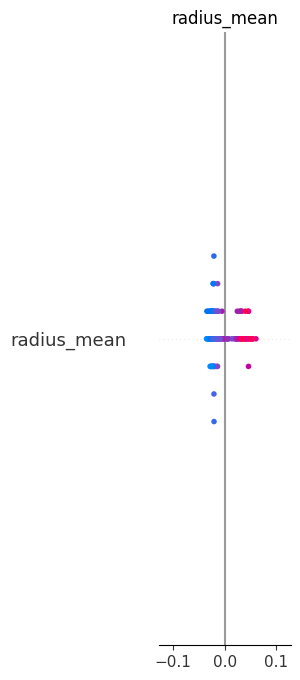

In [133]:
#Visualize the results
#You can now use SHAP’s plotting functions:

#Summary plot – global feature importance:
shap.summary_plot(shap_values, X_test_np, feature_names=feature_names)


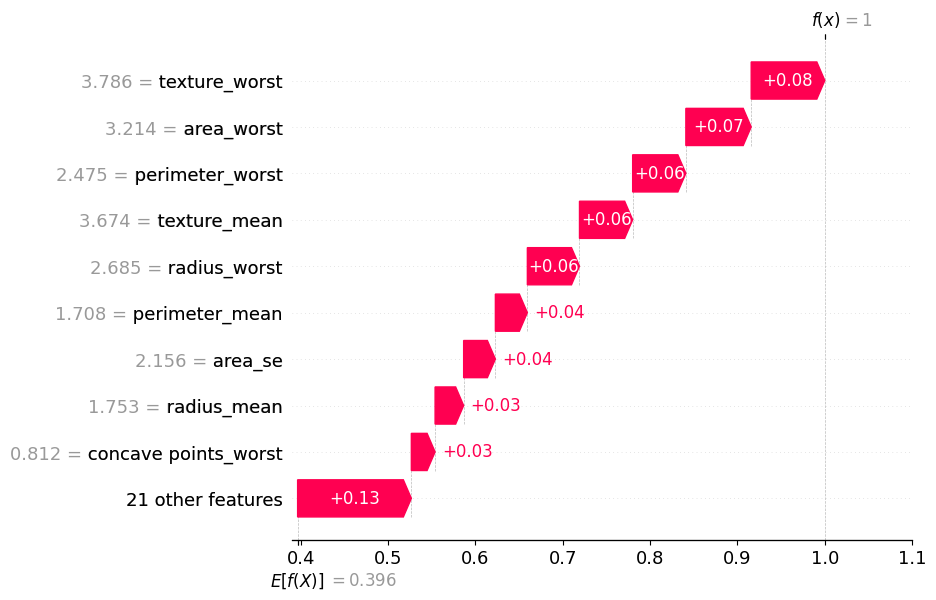

In [134]:
#Waterfall plot – local explanation for a single prediction:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals[0],
        base_values=explainer.expected_value,  # scalar for single output
        data=X_test_np[0],
        feature_names=feature_names
    )
)